In [56]:
import numpy as np

import matplotlib.pylab as plt

dt=0.5
T=100
N=int(T/dt)

P_true=np.zeros(N)
v_true=np.zeros(N)
# 真值
acc_true=5
#bias and noise
acc_bias=np.zeros(N)
acc_p_noise=0.5 #谱密度值
acc_std_noise=acc_p_noise*np.sqrt(dt)
print(acc_std_noise)
bias_rw_std=np.sqrt(0.0009)

acc_mean=np.zeros(N)

#状态序列
P_sim=np.zeros(N)
v_sim=np.zeros(N)

#设初值
P_true[0]=0
P_sim[0]=0
v_true[0]=0
v_sim[0]=0
acc_bias[0]=0

for k in range(1,N):
    # 真值
    v_true[k]=v_true[k-1]+acc_true*dt
    P_true[k]=P_true[k-1]+v_true[k-1]*dt
    #状态
    acc_bias[k]=acc_bias[k-1]+np.random.normal(0,bias_rw_std)
    acc_noise=np.random.normal(0,acc_std_noise)
    acc_mean[k]=acc_true+acc_bias[k]+acc_noise

    v_sim[k]=v_sim[k-1]+acc_mean[k]*dt
    P_sim[k]=P_sim[k-1]+v_sim[k-1]*dt

A=np.array([[1,dt],[0,1]])
B=np.array([[0.5*dt**2],[dt]])

H=np.array([[0,1]])





0.3535533905932738


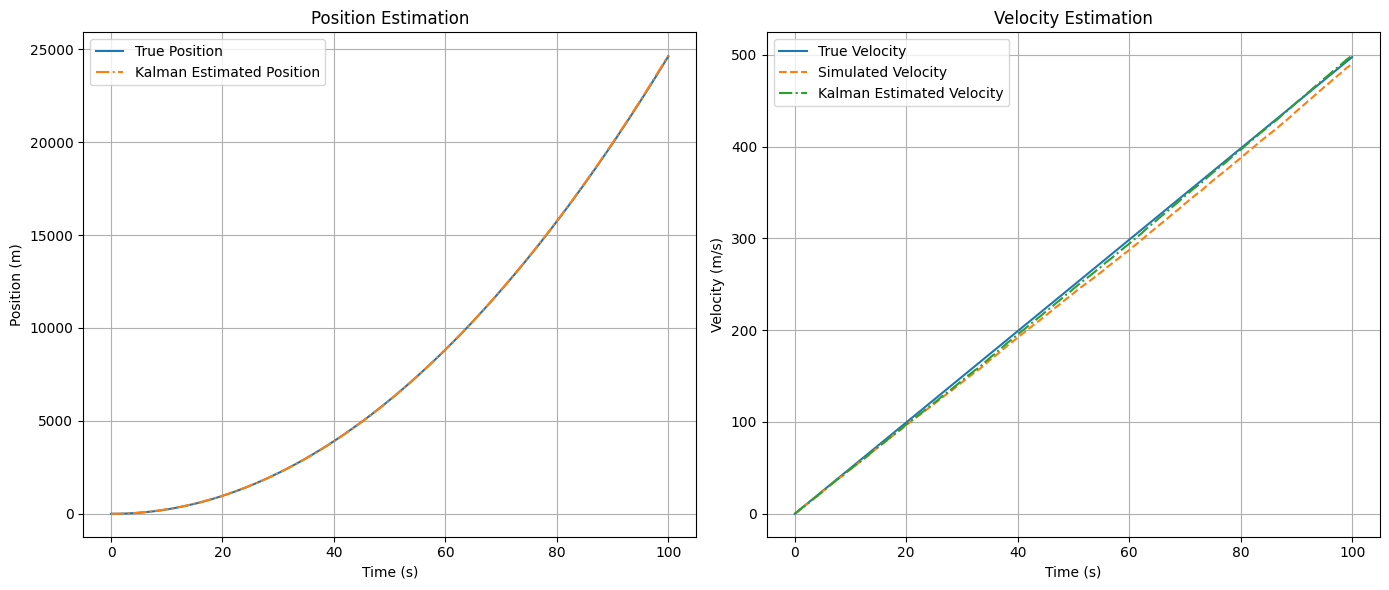

In [57]:
# 噪声协方差设置（可调）
Q = np.array([[[1e-3, 0],
              [0, 1e-3]]])      # 过程噪声
R = np.array([[[1.5 ** 2]]])     # 观测噪声

x_est=np.zeros((2,N))
P_est=np.zeros(((2,2,N)))

z = v_true + np.random.normal(0, 1.5, size=N)
for i in range(0,N):
   x_pred=A@x_est[:,i-1]+B.flatten()*acc_mean[i]
   P_pred=A@P_est[:,:,i-1]@A.T+Q   
#    kalman gain
   k_k=P_pred@H.T@np.linalg.inv(H@P_pred@H.T+R)
   G=(z[i]-H@x_pred)
   x_est[:,i]=x_pred+k_k@G
   P_est[:,:,i]=(np.eye(2)-k_k@H)@P_pred

t = np.linspace(0, T, N)

plt.figure(figsize=(14, 6))

# 位置对比
plt.subplot(1, 2, 1)
plt.plot(t, P_true, label="True Position")
# plt.plot(t, P_sim, label="Simulated Position", linestyle='--')
plt.plot(t, x_est[0], label="Kalman Estimated Position", linestyle='-.')
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Position Estimation")
plt.legend()
plt.grid()

# 速度对比
plt.subplot(1, 2, 2)
plt.plot(t, v_true, label="True Velocity")
plt.plot(t, v_sim, label="Simulated Velocity", linestyle='--')
plt.plot(t, x_est[1], label="Kalman Estimated Velocity", linestyle='-.')
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity Estimation")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

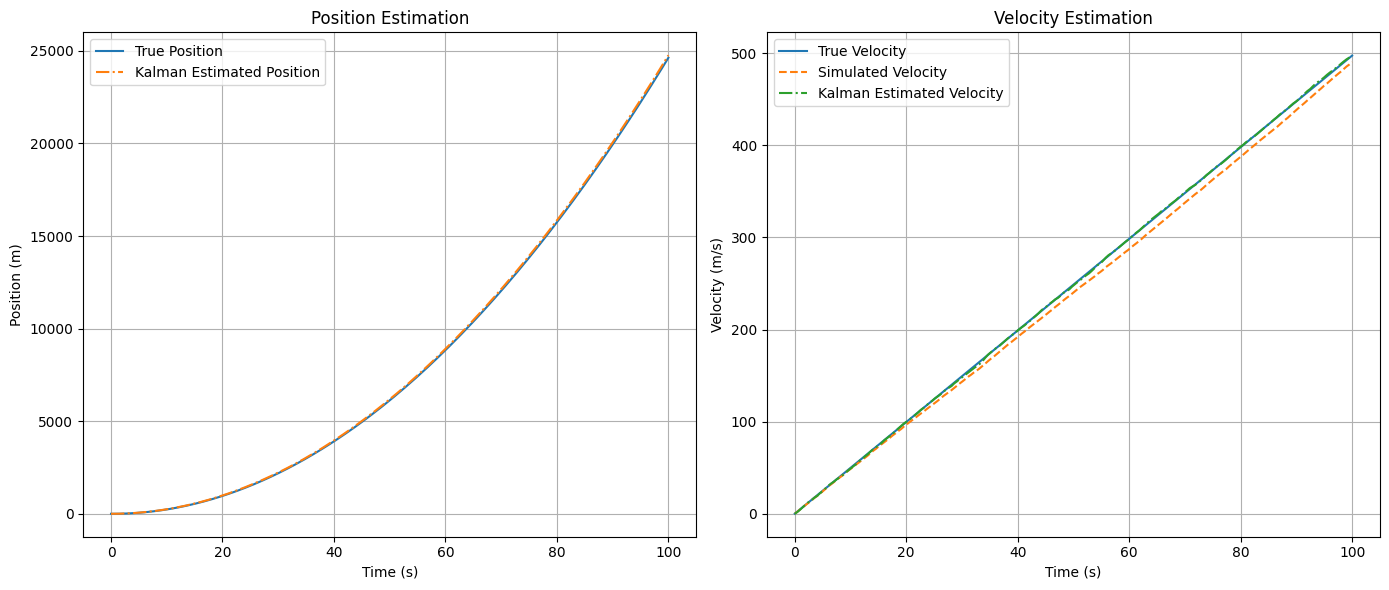

In [58]:
# 噪声协方差设置（可调）
# Q = np.array([[[1e-4, 0],
#               [0, 1e-3]]])      # 过程噪声
Q = np.array([[[1e-1, 0],
              [0, 1e-1]]])      # 过程噪声
R = np.array([[[1.5 ** 2]]])     # 观测噪声

x_est=np.zeros((2,N))
P_est=np.zeros(((2,2,N)))

z = v_true + np.random.normal(0, 1.5, size=N)
for i in range(0,N):
   x_pred=A@x_est[:,i-1]+B.flatten()*acc_mean[i]
   P_pred=A@P_est[:,:,i-1]@A.T+Q   
#    kalman gain
   k_k=P_pred@H.T@np.linalg.inv(H@P_pred@H.T+R)
   G=(z[i]-H@x_pred)
   x_est[:,i]=x_pred+k_k@G
   P_est[:,:,i]=(np.eye(2)-k_k@H)@P_pred

t = np.linspace(0, T, N)

plt.figure(figsize=(14, 6))

# 位置对比
plt.subplot(1, 2, 1)
plt.plot(t, P_true, label="True Position")
# plt.plot(t, P_sim, label="Simulated Position", linestyle='--')
plt.plot(t, x_est[0], label="Kalman Estimated Position", linestyle='-.')
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Position Estimation")
plt.legend()
plt.grid()

# 速度对比
plt.subplot(1, 2, 2)
plt.plot(t, v_true, label="True Velocity")
plt.plot(t, v_sim, label="Simulated Velocity", linestyle='--')
plt.plot(t, x_est[1], label="Kalman Estimated Velocity", linestyle='-.')
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity Estimation")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

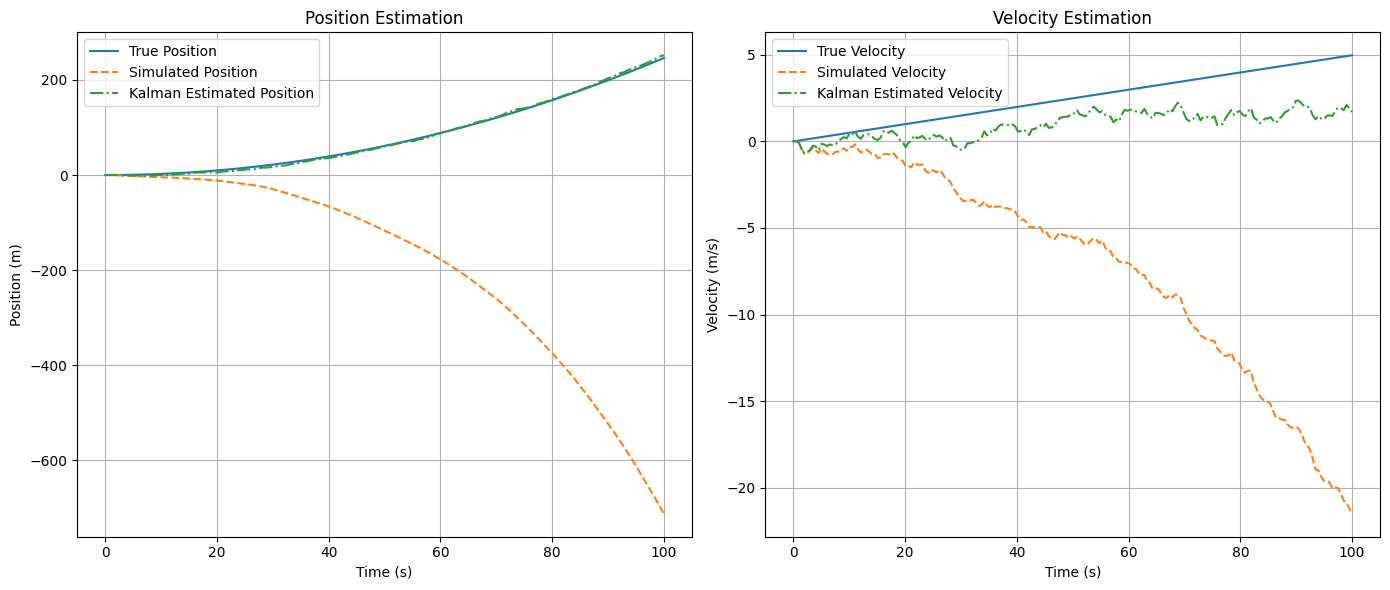

In [36]:
# 噪声协方差设置（可调）
# Q = np.array([[[1e-4, 0],
#               [0, 1e-3]]])      # 过程噪声
Q = np.array([[[1, 0],
              [0, 1]]])      # 过程噪声
R = np.array([[[15 ** 2]]])     # 观测噪声

x_est=np.zeros((2,N))
P_est=np.zeros(((2,2,N)))

z = v_true + np.random.normal(0, 1.5, size=N)
for i in range(0,N):
   x_pred=A@x_est[:,i-1]+B.flatten()*acc_mean[i]
   P_pred=A@P_est[:,:,i-1]@A.T+Q   
#    kalman gain
   k_k=P_pred@H.T@np.linalg.inv(H@P_pred@H.T+R)
   G=(z[i]-H@x_pred)
   x_est[:,i]=x_pred+k_k@G
   P_est[:,:,i]=(np.eye(2)-k_k@H)@P_pred

t = np.linspace(0, T, N)

plt.figure(figsize=(14, 6))

# 位置对比
plt.subplot(1, 2, 1)
plt.plot(t, P_true, label="True Position")
plt.plot(t, P_sim, label="Simulated Position", linestyle='--')
plt.plot(t, x_est[0], label="Kalman Estimated Position", linestyle='-.')
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Position Estimation")
plt.legend()
plt.grid()

# 速度对比
plt.subplot(1, 2, 2)
plt.plot(t, v_true, label="True Velocity")
plt.plot(t, v_sim, label="Simulated Velocity", linestyle='--')
plt.plot(t, x_est[1], label="Kalman Estimated Velocity", linestyle='-.')
# plt.plot(t, z, label="meansure Velocity", linestyle=':')
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity Estimation")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()